In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split




In [74]:
# Data Importation Section
data_path = pd.read_csv(r"C:\Users\user hope\Documents\OILPRED\DataSet\crude-oil-price.csv")
data_path = data_path.dropna()
data_path = data_path.drop_duplicates()
df = pd.DataFrame(data_path)
df.dropna()
df.head(6)



,date,price,percentChange,change
1,1983-04-01 00:00:00+00:00,30.63,4.646,1.36
2,1983-05-01 00:00:00+00:00,30.25,-1.241,-0.38
3,1983-06-01 00:00:00+00:00,31.38,3.736,1.13
4,1983-07-01 00:00:00+00:00,32.00,1.976,0.62
5,1983-08-01 00:00:00+00:00,31.59,-1.281,-0.41
6,1983-09-01 00:00:00+00:00,30.36,-3.894,-1.23


In [75]:
# Adding Price targets to the DataFrame
df['Previous_Year_Price'] = df['price'].shift(12)
df['Next_Month_Price'] = df['price'].shift(-1)
df

,date,price,percentChange,change,Previous_Year_Price,Next_Month_Price
1,1983-04-01 00:00:00+00:00,30.6300,4.646,1.3600,NaN,30.2500
2,1983-05-01 00:00:00+00:00,30.2500,-1.241,-0.3800,NaN,31.3800
3,1983-06-01 00:00:00+00:00,31.3800,3.736,1.1300,NaN,32.0000
4,1983-07-01 00:00:00+00:00,32.0000,1.976,0.6200,NaN,31.5900
5,1983-08-01 00:00:00+00:00,31.5900,-1.281,-0.4100,NaN,30.3600
...,...,...,...,...,...,...
519,2026-06-01 00:00:00+00:00,69.5000,-20.444,-17.8600,65.11,84.6700
520,2026-07-01 00:00:00+00:00,84.6700,21.827,15.1700,69.26,85.7600
521,2026-08-01 00:00:00+00:00,85.7600,1.287,1.0900,64.01,90.4200
522,2026-09-01 00:00:00+00:00,90.4200,5.434,4.6600,62.37,90.3972


In [76]:
# We will create a separate DataFrame for modelling rather than deleting anything(NaN) from your original dataset.
model_data = df.dropna()
model_data.head(12)

,date,price,percentChange,change,Previous_Year_Price,Next_Month_Price
13,1984-04-01 00:00:00+00:00,30.26,-1.912,-0.59,30.63,30.83
14,1984-05-01 00:00:00+00:00,30.83,1.884,0.57,30.25,29.75
15,1984-06-01 00:00:00+00:00,29.75,-3.503,-1.08,31.38,27.60
16,1984-07-01 00:00:00+00:00,27.60,-7.227,-2.15,32.00,29.23
17,1984-08-01 00:00:00+00:00,29.23,5.906,1.63,31.59,29.66
18,1984-09-01 00:00:00+00:00,29.66,1.471,0.43,30.36,28.46
19,1984-10-01 00:00:00+00:00,28.46,-4.046,-1.20,30.37,27.31
20,1984-11-01 00:00:00+00:00,27.31,-4.041,-1.15,29.23,26.41
21,1984-12-01 00:00:00+00:00,26.41,-3.295,-0.90,29.60,26.41
22,1985-01-01 00:00:00+00:00,26.41,0.000,0.00,29.98,26.73


In [77]:
model_data.shape

(510, 6)

# Building ML Model

In [78]:
df.columns  #For our input and target

Index(['date', 'price', 'percentChange', 'change', 'Previous_Year_Price',
       'Next_Month_Price'],
      dtype='str')

In [79]:
X = model_data[['Previous_Year_Price']]
y = model_data['Next_Month_Price']

print('X Shape:', X.shape)
print('y Shape:', y.shape)

print(X.head())
print(y.head())


X Shape: (510, 1)
y Shape: (510,)
    Previous_Year_Price
13                30.63
14                30.25
15                31.38
16                32.00
17                31.59
13    30.83
14    29.75
15    27.60
16    29.23
17    29.66
Name: Next_Month_Price, dtype: float64


In [80]:
split = int(len(model_data)* 0.8)
print(split)
print(len(model_data)- split)

408
102


In [81]:
X_train = X.iloc[:408]
X_test = X.iloc[408:] 
y_train = y.iloc[:408]
y_test = y.iloc[408:]


In [82]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.83]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Previous_Year_Price']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.995
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [83]:
predictions = model.predict(X_test)

In [88]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

In [89]:
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 16.22
RMSE: 20.63


In [91]:
df['target_date'] = df['date'].shift(-1)
model_data = df.dropna(
    subset=['Previous_Year_Price', 'Next_Month_Price']
)


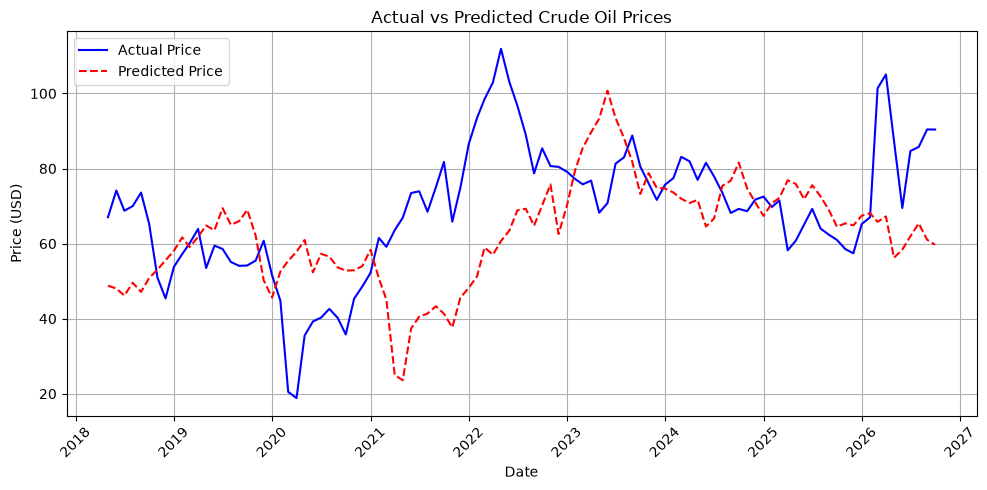

In [100]:
plt.figure(figsize=(10, 5))
model_data['target_date'] = pd.to_datetime(model_data['target_date'])
plt.plot(
    model_data['target_date'].iloc[split:],
    y_test,
    label='Actual Price',
    color='blue'
)

plt.plot(
    model_data['target_date'].iloc[split:],
    predictions,
    label='Predicted Price',
    color='red',
    linestyle='--'
)

plt.title('Actual vs Predicted Crude Oil Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
baseline_predictions = model_data['price'].iloc[split:]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))

Baseline MAE: 5.61
Baseline RMSE: 7.71


In [97]:
print("MODEL COMPARISON")
print("----------------------------------------------->>>>>>")

print("Linear Regression MAE:", round(mae, 2))
print("Baseline MAE:", round(baseline_mae, 2))

print()

print("Linear Regression RMSE:", round(rmse, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))

MODEL COMPARISON
----------------------------------------------->>>>>>
Linear Regression MAE: 16.22
Baseline MAE: 5.61

Linear Regression RMSE: 20.63
Baseline RMSE: 7.71


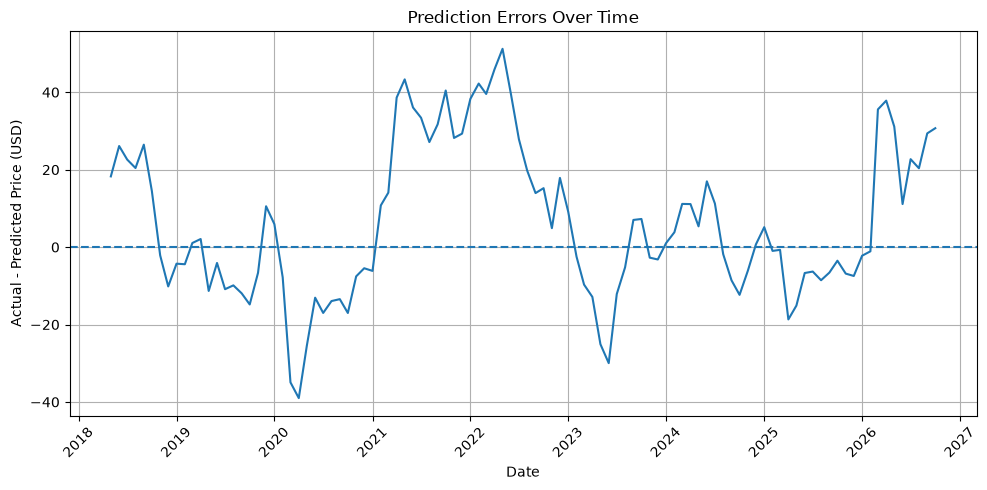

In [101]:
errors = y_test - predictions

plt.figure(figsize=(10, 5))

plt.plot(
    model_data['target_date'].iloc[split:],
    errors
)

plt.axhline(y=0, linestyle='--')

plt.title('Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Actual - Predicted Price (USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

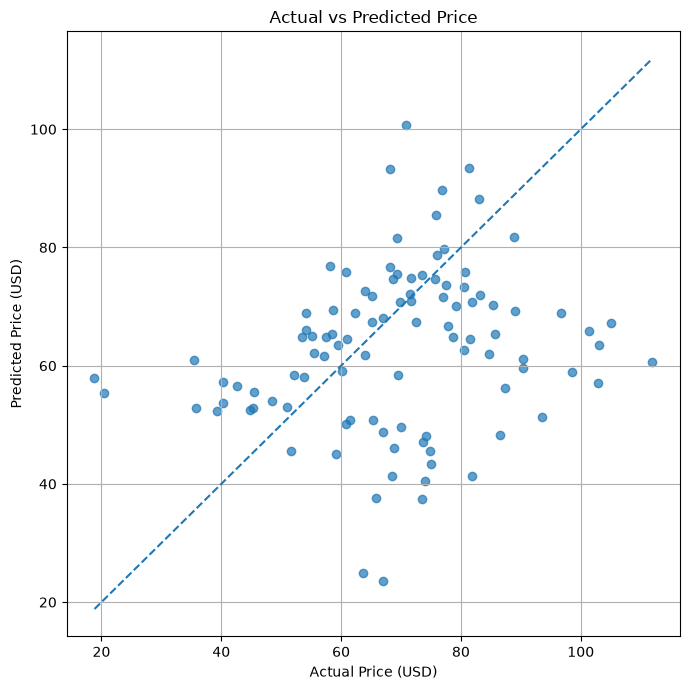

In [99]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, predictions, alpha=0.7)

minimum = min(y_test.min(), predictions.min())
maximum = max(y_test.max(), predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--'
)

plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [102]:
results = pd.DataFrame({
    'Date': model_data['target_date'].iloc[split:].values,
    'Actual_Price': y_test.values,
    'Predicted_Price': predictions
})

results['Error'] = (
    results['Actual_Price'] - results['Predicted_Price']
)

results['Absolute_Error'] = results['Error'].abs()

results.head(10)

,Date,Actual_Price,Predicted_Price,Error,Absolute_Error
0,2018-05-01,67.0400,48.781780,18.258220,18.258220
1,2018-06-01,74.1500,48.044122,26.105878,26.105878
2,2018-07-01,68.7600,46.154392,22.605608,22.605608
3,2018-08-01,69.9977,49.577456,20.420244,20.420244
4,2018-09-01,73.5992,47.140699,26.458501,26.458501
5,2018-10-01,65.3100,50.820699,14.489301,14.489301
6,2018-11-01,50.9300,53.066826,-2.136826,2.136826
7,2018-12-01,45.4100,55.569889,-10.159889,10.159889
8,2019-01-01,53.7900,58.072952,-4.282952,4.282952
9,2019-02-01,57.2200,61.645205,-4.425205,4.425205
